# numpy.polyfit
## numpy.polyfit(x, y, deg, rcond=None, full=False, w=None, cov=False)
## deg: Degree of the fitting polynomial. ie deg=1,  y = a + bx
### Least squares polynomial fit.

In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
x = np.array([1,2,3,4,5,6,7,8,9])
y = np.array([2.8, 3.2, 4.1, 5.9, 6.6, 7.3, 8.0, 10, 11])

b, a = np.polyfit(x, y, deg=1)

In [3]:
b

np.float64(1.04)

In [4]:
a

np.float64(1.3444444444444434)

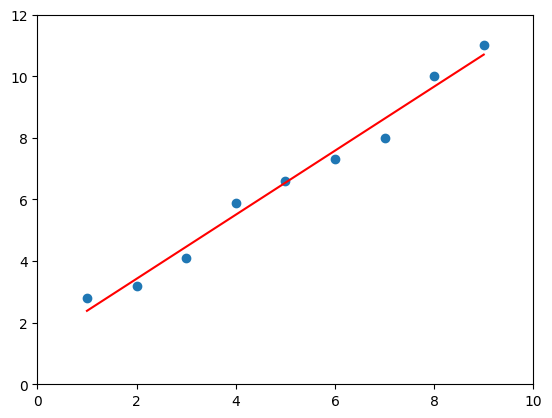

In [5]:
plt.plot(x, y, 'o')
plt.plot(x, a+b*x , 'r-')
plt.xlim(0, 10)
plt.ylim(0, 12)
plt.show()

In [6]:
df = yf.download('^HSI', start='2025-01-01', end=None, 
                 progress=False).droplevel('Ticker', axis=1).reset_index()
df

YF.download() has changed argument auto_adjust default to True


Price,Date,Close,High,Low,Open,Volume
0,2025-01-02,19623.320312,19932.800781,19542.980469,19932.800781,4033400000
1,2025-01-03,19760.269531,19891.859375,19634.070312,19708.740234,3393800000
2,2025-01-06,19688.289062,19851.550781,19627.839844,19848.710938,2465700000
3,2025-01-07,19447.580078,19668.650391,19252.609375,19501.449219,3581000000
4,2025-01-08,19279.839844,19483.589844,19111.539062,19390.759766,3232400000
...,...,...,...,...,...,...
63,2025-04-07,19828.300781,21047.830078,19706.029297,20730.050781,12686500000
64,2025-04-08,20127.679688,20454.259766,19745.140625,20157.519531,8420700000
65,2025-04-09,20264.490234,20441.140625,19260.210938,19494.919922,8672400000
66,2025-04-10,20681.779297,21211.130859,20530.429688,20810.429688,6611800000


In [7]:
df

Price,Date,Close,High,Low,Open,Volume
0,2025-01-02,19623.320312,19932.800781,19542.980469,19932.800781,4033400000
1,2025-01-03,19760.269531,19891.859375,19634.070312,19708.740234,3393800000
2,2025-01-06,19688.289062,19851.550781,19627.839844,19848.710938,2465700000
3,2025-01-07,19447.580078,19668.650391,19252.609375,19501.449219,3581000000
4,2025-01-08,19279.839844,19483.589844,19111.539062,19390.759766,3232400000
...,...,...,...,...,...,...
63,2025-04-07,19828.300781,21047.830078,19706.029297,20730.050781,12686500000
64,2025-04-08,20127.679688,20454.259766,19745.140625,20157.519531,8420700000
65,2025-04-09,20264.490234,20441.140625,19260.210938,19494.919922,8672400000
66,2025-04-10,20681.779297,21211.130859,20530.429688,20810.429688,6611800000


In [8]:
b, a = np.polyfit(df.index, df.Close, deg=1)

In [9]:
np.poly1d(np.polyfit(df.index, df.Close, deg=2))(df.index)  

array([17691.2873834 , 17939.82180273, 18182.72549582, 18419.99846266,
       18651.64070325, 18877.65221759, 19098.03300568, 19312.78306753,
       19521.90240312, 19725.39101247, 19923.24889557, 20115.47605242,
       20302.07248303, 20483.03818738, 20658.37316549, 20828.07741735,
       20992.15094296, 21150.59374232, 21303.40581544, 21450.5871623 ,
       21592.13778292, 21728.05767729, 21858.34684541, 21983.00528728,
       22102.0330029 , 22215.42999228, 22323.19625541, 22425.33179229,
       22521.83660292, 22612.7106873 , 22697.95404543, 22777.56667732,
       22851.54858296, 22919.89976235, 22982.62021549, 23039.70994238,
       23091.16894303, 23136.99721742, 23177.19476557, 23211.76158747,
       23240.69768312, 23264.00305252, 23281.67769568, 23293.72161259,
       23300.13480324, 23300.91726765, 23296.06900581, 23285.59001773,
       23269.48030339, 23247.73986281, 23220.36869598, 23187.3668029 ,
       23148.73418357, 23104.47083799, 23054.57676617, 22999.0519681 ,
      

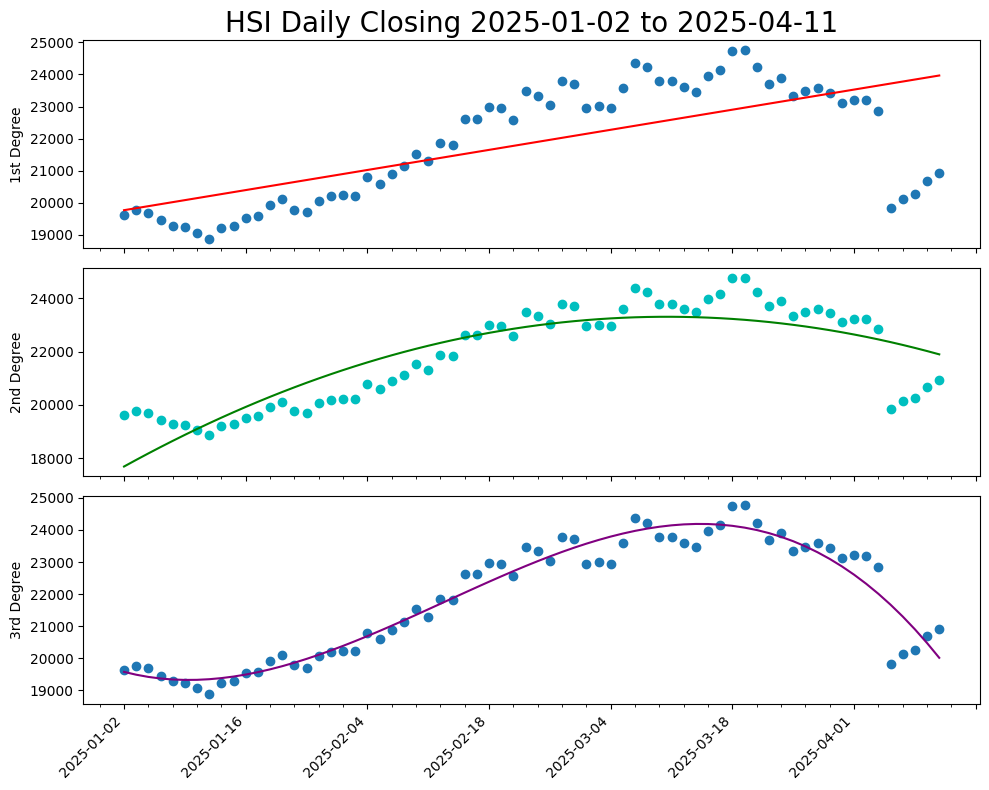

In [14]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10,8), sharex=True)

ax[0].set_title(f'HSI Daily Closing {df.Date.astype(str)[0]} to {df.Date.astype(str).iloc[-1]}', fontsize=20)
ax[0].plot(df.Date.astype(str), df.Close, 'o')
ax[0].plot(df.Date.astype(str), a+b*df.index, 'r-')  #  a+b*df.index,
ax[0].set_ylabel('1st Degree')

ax[1].plot(df.Date.astype(str), df.Close, 'co')
ax[1].plot(df.Date.astype(str), np.poly1d(np.polyfit(df.index, df.Close, deg=2))(df.index), 'g-')
ax[1].set_ylabel('2nd Degree')

ax[2].plot(df.Date.astype(str), df.Close, 'o')
ax[2].plot(df.Date.astype(str), np.poly1d(np.polyfit(df.index, df.Close, deg=3))(df.index), 'purple')
ax[2].set_ylabel('3rd Degree')

ax[2].set_xticks(df.Date.astype(str), labels=df.Date.astype(str), rotation=45, ha='right')
ax[2].xaxis.set_major_locator(ticker.AutoLocator())
ax[2].xaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
plt.show()

In [11]:
np.polyfit(df.index, df.Close, deg=1)

array([   62.72045314, 19766.21000589])

In [12]:
np.polyfit(df.index, df.Close, deg=2)

array([-2.81536312e+00,  2.51349782e+02,  1.76912874e+04])

In [13]:
np.polyfit(df.index, df.Close, deg=3)

array([-1.30925696e-01,  1.03426693e+01, -9.86800664e+01,  1.95728860e+04])

In [33]:
def forecast(d):
    sum_index=0
    for i in range (1+d+1):  # Degree
        sum_index+=np.poly1d(np.polyfit(df.index,df.Close,deg=i))(68)
        print (f"i: ",i, "sum_index: ",sum_index,"sum_index/d :",sum_index/d,end='\n')
    return sum_index/d

forecast(10)

i:  0 sum_index:  21867.345186121325 sum_index/d : 2186.7345186121324
i:  1 sum_index:  45898.54600561074 sum_index/d : 4589.854600561074
i:  2 sum_index:  67663.37951016141 sum_index/d : 6766.337951016141
i:  3 sum_index:  87183.29556418289 sum_index/d : 8718.329556418288
i:  4 sum_index:  106792.46468316966 sum_index/d : 10679.246468316966
i:  5 sum_index:  126075.83256337154 sum_index/d : 12607.583256337155
i:  6 sum_index:  145428.9314277682 sum_index/d : 14542.89314277682
i:  7 sum_index:  165571.3498239211 sum_index/d : 16557.134982392112
i:  8 sum_index:  186961.17616470443 sum_index/d : 18696.117616470445
i:  9 sum_index:  209012.42800297652 sum_index/d : 20901.242800297652
i:  10 sum_index:  231182.66997493786 sum_index/d : 23118.266997493785
i:  11 sum_index:  255360.71247203537 sum_index/d : 25536.071247203537


np.float64(25536.071247203537)